In [1]:
from joblib import load
from pathlib import Path
from joblib import load

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [ ]:
from sklearn.metrics import (PrecisionRecallDisplay,
                             ConfusionMatrixDisplay,
                             PredictionErrorDisplay,
                             classification_report,
                             mean_squared_error,
                             mean_absolute_error,
                             r2_score)

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')

In [6]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id').reset_index(drop=True)
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)
train_X.shape

(850, 1, 100)

In [7]:

test = pd.read_csv(data_dir / 'test_ts.csv', index_col='id').reset_index(drop=True)
test['action'] = test['genre'].map(lambda x: 'Action' in x)
test_X = test[[str(i) for i in range(100)]].values.reshape(len(test), 1, 100)
test_X.shape

(284, 1, 100)

In [8]:
models_dir = data_dir / 'models'
models = {}
for file in models_dir.glob('*.pkl'):
    name = file.stem
    with open(file, 'rb') as infile:
        models[name] = load(file)

## Action

In [9]:
test_y = test['action']
train_y = train['action']

### KNN with Catch22 features

In [10]:
models['c22_action']

,estimator,Catch22Classi...ycatch22=True)
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,n_estimators,200
,criterion,'gini'


In [11]:
y_pred = models['c22_action'].predict(test_X)

In [12]:
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

       False       0.85      0.68      0.76       195
        True       0.52      0.74      0.61        89

    accuracy                           0.70       284
   macro avg       0.68      0.71      0.68       284
weighted avg       0.75      0.70      0.71       284



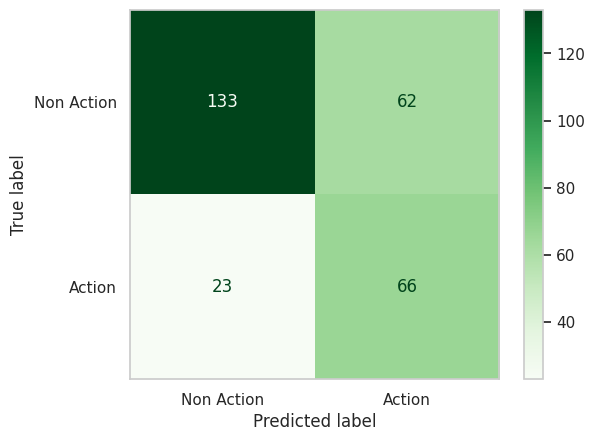

In [13]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred, cmap='Greens', display_labels=('Non Action', 'Action'))
plt.grid(False)

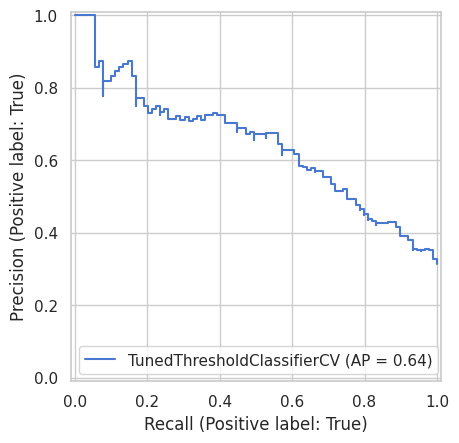

In [14]:
PrecisionRecallDisplay.from_estimator(models['c22_action'], test_X, test_y)

### Random Shapelets Classifier

We already tuned the model threshold.

In [15]:
models['rst']

,estimator,ShapeletTrans...ndom_state=42)
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,True
,n_estimators,100
,criterion,'gini'


In [16]:
y_pred_rst = models['rst'].predict(test_X)
print(classification_report(test_y, y_pred_rst))

              precision    recall  f1-score   support

       False       0.83      0.78      0.81       195
        True       0.58      0.65      0.61        89

    accuracy                           0.74       284
   macro avg       0.71      0.72      0.71       284
weighted avg       0.75      0.74      0.75       284



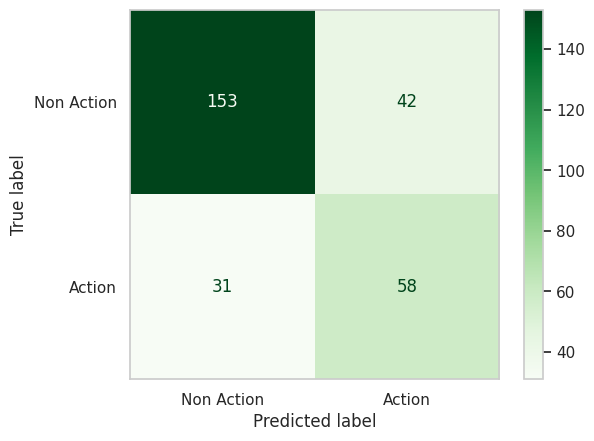

In [17]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred_rst, cmap='Greens', display_labels=('Non Action', 'Action'))
plt.grid(False)

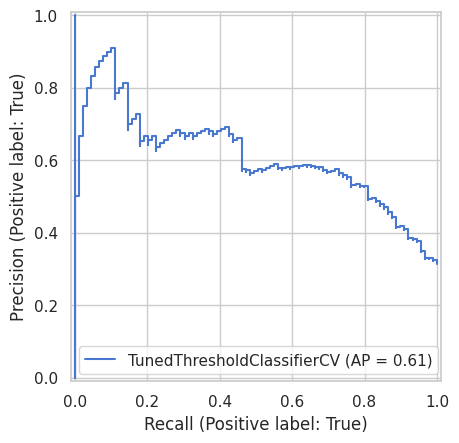

In [18]:
PrecisionRecallDisplay.from_estimator(models['rst'], test_X, test_y)

Looks like there is one high ranking false positive.

In [19]:
y_score = models['rst'].predict_proba(test_X)
y_score[:,1].argsort()[-1:]

array([47])

In [20]:
test.iloc[47,:]

title              Annihilation
startYear                  2018
runtimeMinutes              115
numVotes                 383786
countryOfOrigin           US,GB
                       ...     
96                      22459.0
97                      21174.0
98                      19160.0
99                      16716.0
action                    False
Name: 47, Length: 114, dtype: object

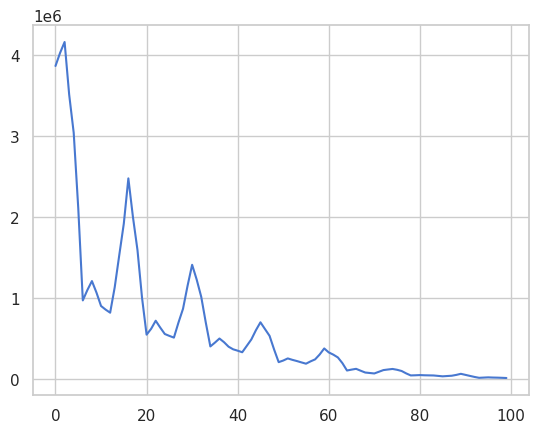

In [21]:
plt.plot(test_X[47][0])

### TSF

In [22]:
models['tsf_action']

,estimator,Pipeline(step...m_state=42))])
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,42
,store_cv_results,False
,base_estimator,None
,n_estimators,200


In [23]:
y_pred = models['tsf_action'].predict(test_X)
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

       False       0.84      0.55      0.66       195
        True       0.44      0.76      0.56        89

    accuracy                           0.62       284
   macro avg       0.64      0.66      0.61       284
weighted avg       0.71      0.62      0.63       284



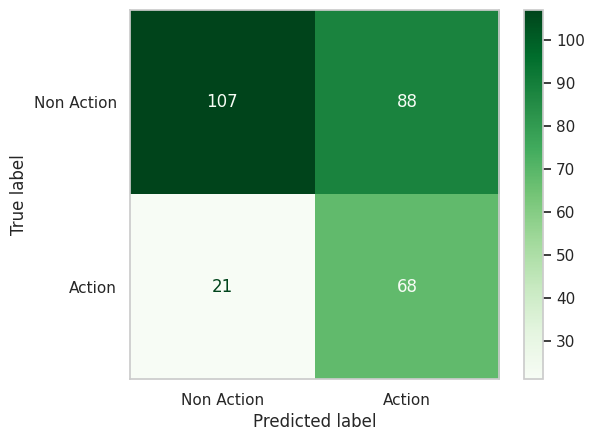

In [24]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred, cmap='Greens', display_labels=('Non Action', 'Action'))
plt.grid(False)

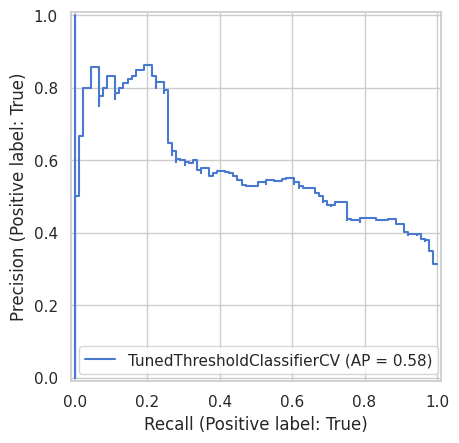

In [25]:
PrecisionRecallDisplay.from_estimator(models['tsf_action'], test_X, test_y)

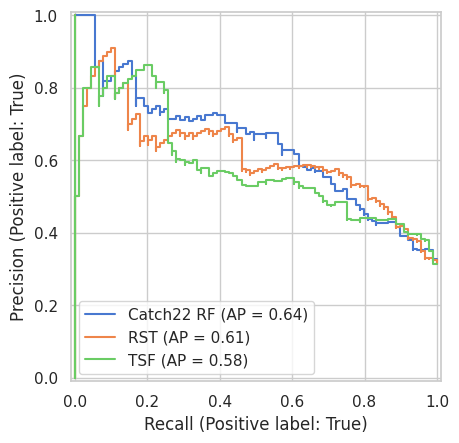

In [26]:
fig, axs = plt.subplots()
PrecisionRecallDisplay.from_estimator(models['c22_action'], test_X, test_y,
                                      name='Catch22 RF', ax=axs)
PrecisionRecallDisplay.from_estimator(models['rst'], test_X, test_y,
                                      name='RST', ax=axs)
PrecisionRecallDisplay.from_estimator(models['tsf_action'], test_X, test_y,
                                      name='TSF', ax=axs)


## Rating category

In [27]:
test_y = test['rating_category']

### Feature based

In [28]:
models['c22_rating']

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,"RandomForestC...50, n_jobs=-1)"
,random_state,None
,n_jobs,1
,parallel_backend,None
,class_weight,None
,n_estimators,50


In [29]:
y_pred = models['c22_rating'].predict(test_X)
print(classification_report(test_y, y_pred, zero_division=0))

              precision    recall  f1-score   support

        High       0.61      0.60      0.61        95
         Low       0.00      0.00      0.00         2
      Medium       0.46      0.65      0.53        96
 Medium High       0.36      0.21      0.27        61
  Medium Low       0.37      0.23      0.29        30

    accuracy                           0.49       284
   macro avg       0.36      0.34      0.34       284
weighted avg       0.48      0.49      0.47       284



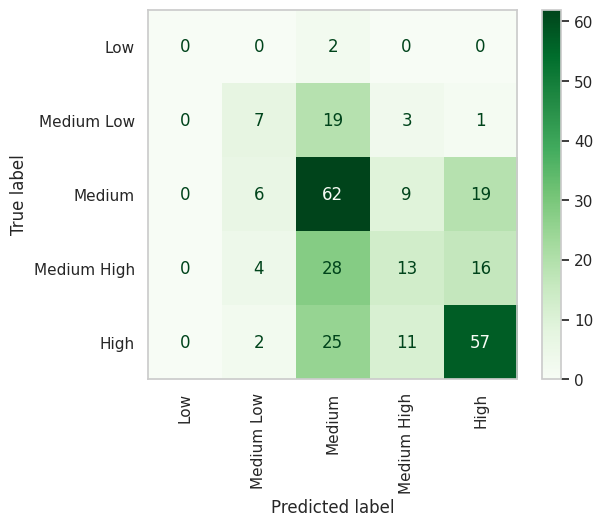

In [30]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred, cmap='Greens', labels=('Low', 'Medium Low', 'Medium', 'Medium High', 'High'), xticks_rotation='vertical')
plt.grid(False)

### TSF

In [31]:
models['tsf_rating']

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,base_estimator,None
,n_estimators,5
,n_intervals,'sqrt'
,min_interval_length,28
,max_interval_length,inf
,time_limit_in_minutes,None
,contract_max_n_estimators,500


In [32]:
y_pred = models['tsf_rating'].predict(test_X)
print(classification_report(test_y, y_pred, zero_division=0))

              precision    recall  f1-score   support

        High       0.49      0.58      0.53        95
         Low       0.00      0.00      0.00         2
      Medium       0.44      0.54      0.49        96
 Medium High       0.21      0.11      0.15        61
  Medium Low       0.26      0.17      0.20        30

    accuracy                           0.42       284
   macro avg       0.28      0.28      0.27       284
weighted avg       0.39      0.42      0.40       284



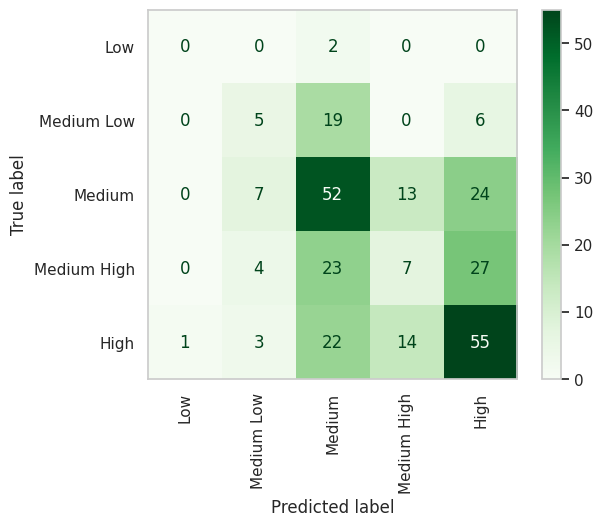

In [33]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred, cmap='Greens', labels=('Low', 'Medium Low', 'Medium', 'Medium High', 'High'), xticks_rotation='vertical')
plt.grid(False)

## and regression

In [34]:
test_y = test['rating']
train_y = train['rating']

### Feature based

In [35]:
models['c22_regressor']

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,"RandomForestR...00, n_jobs=-1)"
,random_state,None
,n_jobs,1
,parallel_backend,None
,n_estimators,200
,criterion,'squared_error'


In [36]:
y_pred = models['c22_regressor'].predict(test_X)
print("Mean Squared error:", round(mean_squared_error(test_y, y_pred), 2))
print("Mean Absolute error:", round(mean_absolute_error(test_y, y_pred), 2))
print("R2 score:", round(r2_score(test_y, y_pred), 2))

Mean Squared error: 0.53
Mean Absolute error: 0.55
R2 score: 0.34


In [37]:
stat, pvalue = pearsonr(test_y, y_pred)
print(f'Pearson R {round(stat, 2)}, p value: {round(pvalue, 2)}')

Pearson R 0.58, p value: 0.0


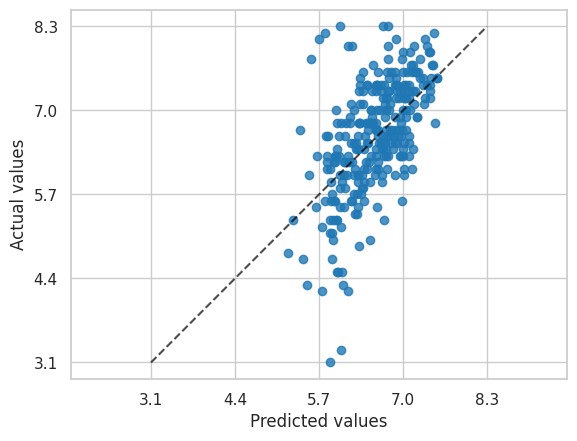

In [38]:
PredictionErrorDisplay.from_predictions(test_y, y_pred, kind='actual_vs_predicted')
plt.show()

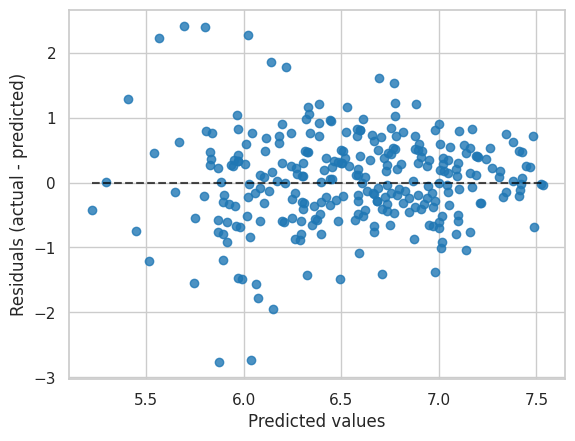

In [39]:
PredictionErrorDisplay.from_predictions(test_y, y_pred)
plt.show()

## TSF

In [40]:
models['tsf_regression']

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,base_estimator,None
,n_estimators,100
,n_intervals,'sqrt'
,min_interval_length,7
,max_interval_length,inf
,time_limit_in_minutes,None
,contract_max_n_estimators,500


In [41]:
y_pred = models['tsf_regression'].predict(test_X)
print('Mean Squared error:', round(mean_squared_error(test_y, y_pred), 2))
print('Mean Absolute error:', round(mean_absolute_error(test_y, y_pred), 2))
print('R2 Score: ', round(r2_score(test_y, y_pred), 2))

Mean Squared error: 0.57
Mean Absolute error: 0.57
R2 Score:  0.29


In [42]:
stat, pvalue = pearsonr(test_y, y_pred)
print(f'Pearson R: {round(stat, 2)}, p value: {round(pvalue, 2)}')

Pearson R: 0.54, p value: 0.0


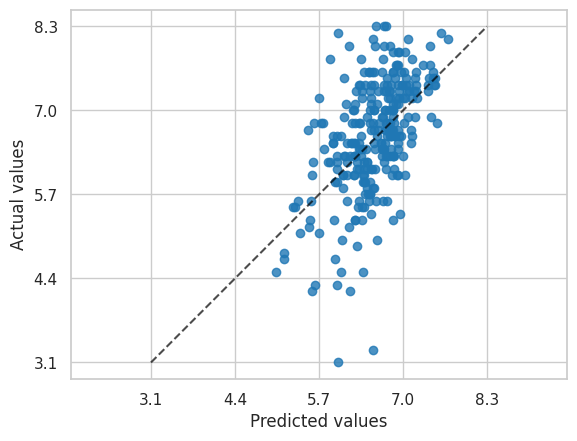

In [43]:
PredictionErrorDisplay.from_predictions(test_y, y_pred, kind='actual_vs_predicted')
plt.show()

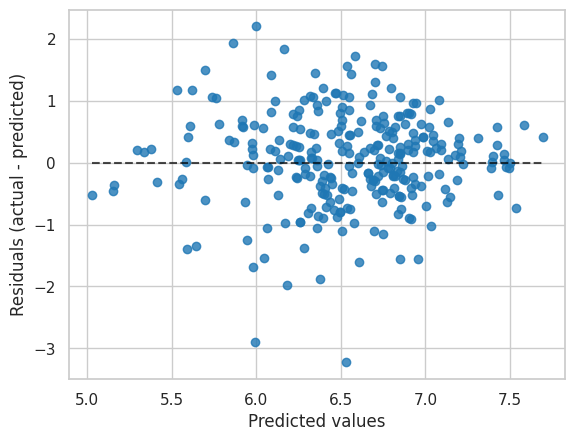

In [44]:
PredictionErrorDisplay.from_predictions(test_y, y_pred)
plt.show()